In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
print(pd.__version__)

2.2.2


## Loading Data and Initial Exploration

In [5]:
df=pd.read_csv("/content/laptop_data.csv")
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [6]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [8]:
df.shape

(1303, 12)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [13]:
df.drop(columns=['Unnamed: 0'],inplace=True,errors='ignore')

In [14]:
df.duplicated().sum()

np.int64(29)

In [15]:
df[df.duplicated()]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1274,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.3200
1275,Asus,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.2kg,38841.1200
1276,Dell,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,6GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.3kg,24455.5200
1277,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg,15397.9200
1278,Dell,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,500GB HDD,Intel HD Graphics,Windows 10,2.20kg,20193.1200
1279,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.6kg,47898.7200
1280,HP,Notebook,15.6,Full HD 1920x1080,AMD A9-Series 9410 2.9GHz,6GB,1.0TB Hybrid,AMD Radeon R7 M440,Windows 10,2.04kg,29303.4672
1281,Dell,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R5 M430,Linux,2.3kg,42943.1472
1282,HP,Netbook,11.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.17kg,11135.5200
1283,Asus,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,38378.6496


## Exploratory Data Analysis and Data Cleaning

RAM

In [16]:
print(df['Ram'].value_counts())
print("-"*30)
print("Total no. of categories in Ram:",len(df['Ram'].value_counts()))

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64
------------------------------
Total no. of categories in Ram: 9


<Axes: xlabel='Ram'>

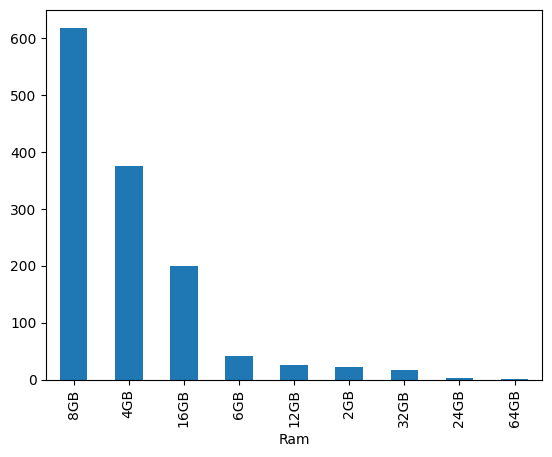

In [17]:
#Barplot for value counts
df['Ram'].value_counts().plot(kind='bar')

In [18]:
#Ram = Replacing GB with blanks and replacing kg to blanks
df['Ram'] = df['Ram'].str.replace('GB','')
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


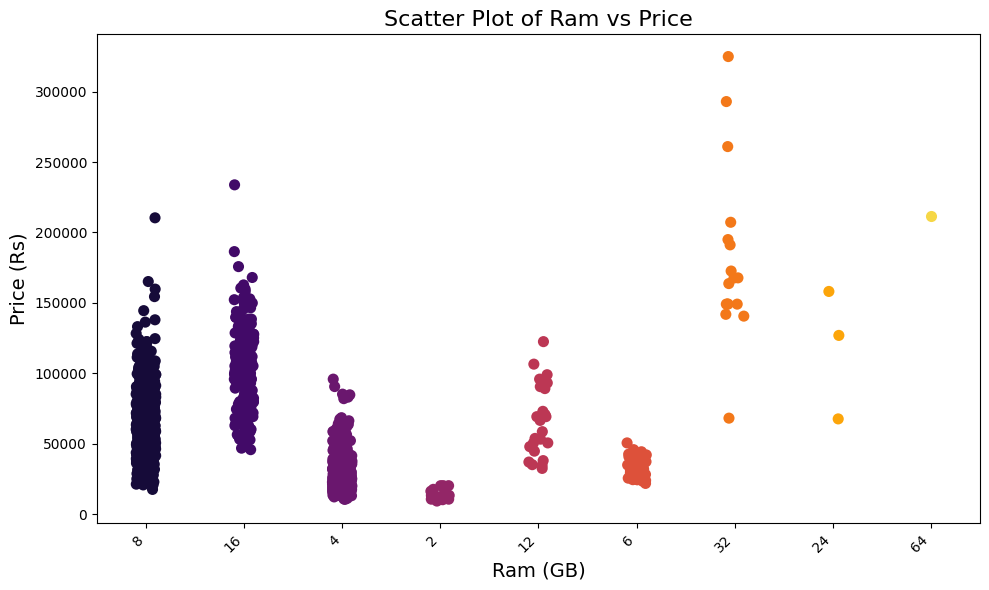

In [19]:
## Strip plot for Ram vs Prive
plt.figure(figsize=(10, 6))
sns.stripplot(x='Ram', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Ram (GB)', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Ram vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

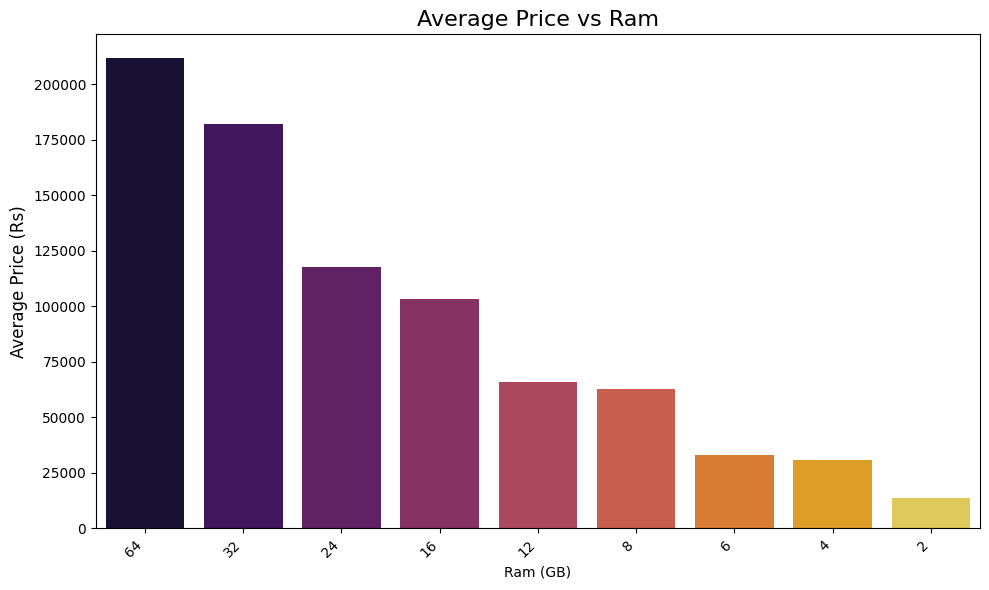

In [20]:
# Calculate mean prices for each RAM category
mean_prices = df.groupby('Ram')['Price'].mean().reset_index()

# Sort the mean prices in descending order
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Ram', y='Price', data=mean_prices, palette='inferno')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('Ram (GB)', fontsize=10)
plt.ylabel('Average Price (Rs)', fontsize=12)
plt.title('Average Price vs Ram', fontsize=16)
plt.tight_layout()
plt.show()

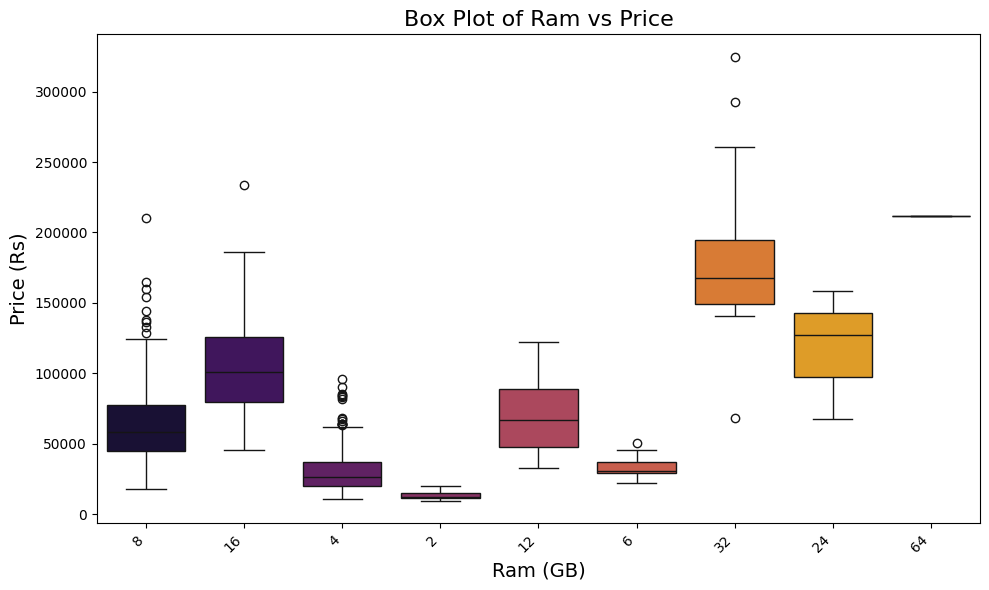

In [21]:
## Boxplot for Ram vs Price
plt.figure(figsize=(10, 6))
sns.boxplot(x='Ram', y='Price', data=df, palette='inferno')
plt.xlabel('Ram (GB)', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Box Plot of Ram vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
sorted_df = df.sort_values(by='Price', ascending=False)
sorted_df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,324954.720
830,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,512GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,292986.720
610,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.5kg,261018.720
749,HP,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Xeon E3-1535M v5 2.9GHz,16,256GB SSD,Nvidia Quadro M2000M,Windows 7,3kg,233845.920
1066,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,64,1TB SSD,Nvidia GeForce GTX 980,Windows 10,3.58kg,211788.000
...,...,...,...,...,...,...,...,...,...,...,...
290,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2,16GB SSD,Intel HD Graphics,Chrome OS,2.19kg,10602.720
31,Asus,Notebook,14.0,1366x768,AMD E-Series E2-6110 1.5GHz,2,32GB Flash Storage,AMD Radeon R2,Windows 10,1.65kg,10602.720
1120,Vero,Notebook,13.3,Full HD 1920x1080,Intel Atom X5-Z8350 1.44GHz,4,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.35kg,10442.880
20,Asus,Netbook,11.6,1366x768,Intel Atom x5-Z8350 1.44GHz,2,32GB Flash Storage,Intel HD Graphics 400,Windows 10,0.98kg,10224.432


In [24]:
#converting Ram to integer type
df["Ram"] = df["Ram"].astype('int64')
df["Ram"]

,Ram
0,8
1,8
2,8
3,16
4,8
...,...
1298,4
1299,16
1300,2
1301,6


**RAM is sorted now**

###Weight

In [25]:
## Removing kg from the weight feature
df['Weight'] = df['Weight'].str.replace('kg','')
df['Weight']

,Weight
0,1.37
1,1.34
2,1.86
3,1.83
4,1.37
...,...
1298,1.8
1299,1.3
1300,1.5
1301,2.19


In [26]:
len(df['Weight'].value_counts())

179

In [27]:
#converting weight to float
df['Weight']=df['Weight'].astype('float64')
df['Weight']

,Weight
0,1.37
1,1.34
2,1.86
3,1.83
4,1.37
...,...
1298,1.80
1299,1.30
1300,1.50
1301,2.19


<Axes: xlabel='Weight', ylabel='Count'>

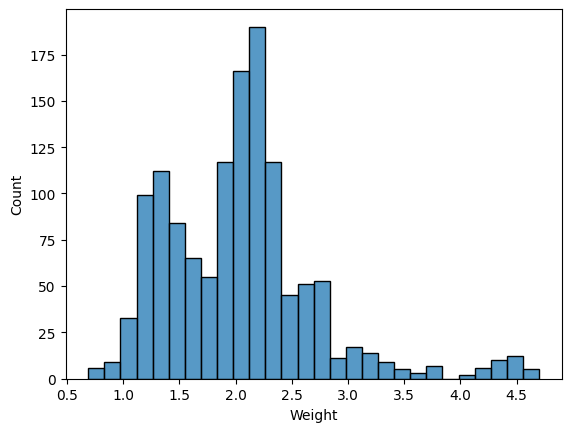

In [29]:
# histogram of weight
sns.histplot(df["Weight"],kde=False)

**Most of the laptops have weight between 1 - 2.7 kgs**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 112.1+ KB


In [31]:
df['Weight'].max()

4.7

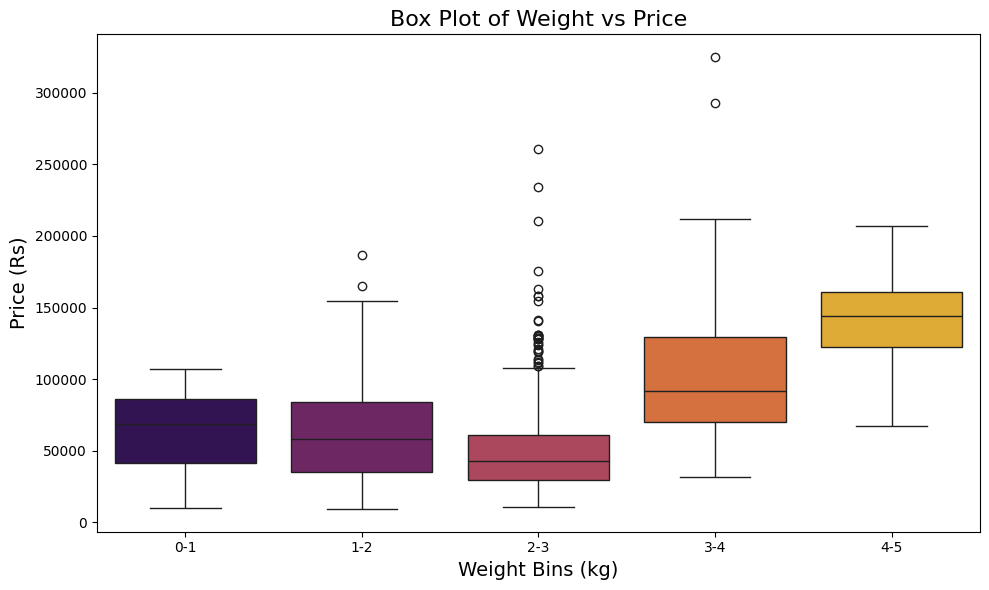

In [33]:
#Weight vs Price
# Bin the Weight into categories
bins = [0, 1, 2, 3, 4, 5]  # Adjust bin edges as necessary
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']
df['Weight_Binned'] = pd.cut(df['Weight'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Weight_Binned', y='Price', data=df, palette='inferno')
plt.xlabel('Weight Bins (kg)', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Box Plot of Weight vs Price', fontsize=16)
plt.tight_layout()
plt.show()

**Weight is sorted**

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Company           1303 non-null   object  
 1   TypeName          1303 non-null   object  
 2   Inches            1303 non-null   float64 
 3   ScreenResolution  1303 non-null   object  
 4   Cpu               1303 non-null   object  
 5   Ram               1303 non-null   int64   
 6   Memory            1303 non-null   object  
 7   Gpu               1303 non-null   object  
 8   OpSys             1303 non-null   object  
 9   Weight            1303 non-null   float64 
 10  Price             1303 non-null   float64 
 11  Weight_Binned     1303 non-null   category
dtypes: category(1), float64(3), int64(1), object(7)
memory usage: 113.6+ KB


### Price - Target Feature

<Axes: xlabel='Price', ylabel='Count'>

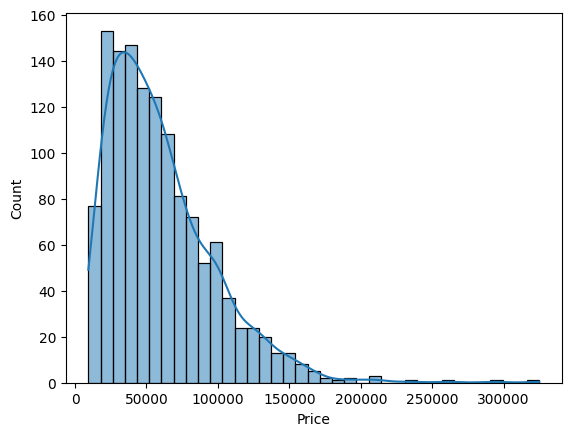

In [36]:
sns.histplot(df['Price'], kde=True)

In [37]:
print(df['Price'].mean())
print(df['Price'].median())

59870.042910207216
52054.56


- **Mean price of the laptops around = 60k**
- **Median price of the laptops around = 52k**

### Company / Brand Name

<Axes: xlabel='Company'>

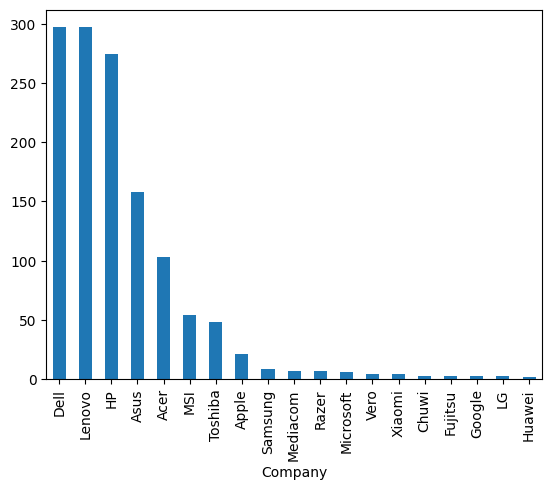

In [38]:
#company wise laptop counts and their plot
df['Company'].value_counts().plot(kind='bar')

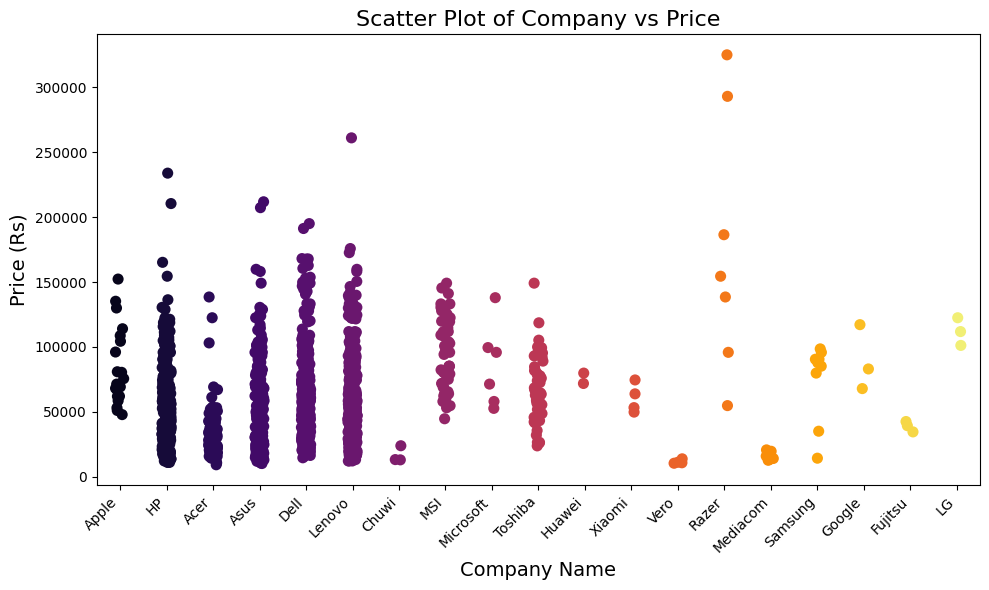

In [39]:
## Strip plot for Company vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='Company', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Company Name', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Company vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

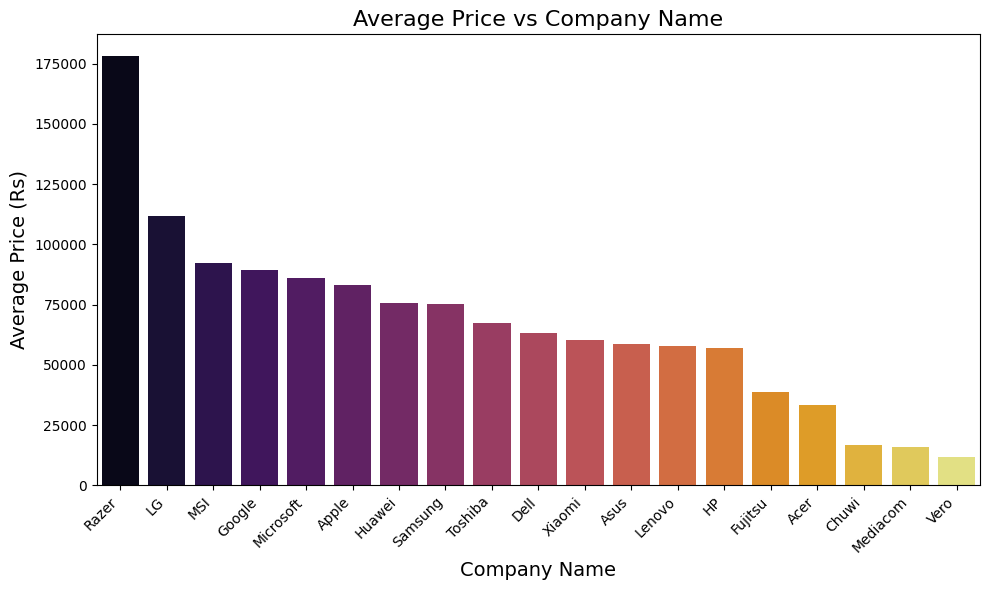

In [40]:
# Calculate mean prices for each RAM category
mean_prices = df.groupby('Company')['Price'].mean().reset_index()

# Sort the mean prices in descending order
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Company', y='Price', data=mean_prices, palette='inferno')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('Company Name', fontsize=14)
plt.ylabel('Average Price (Rs)', fontsize=14)
plt.title('Average Price vs Company Name', fontsize=16)
plt.tight_layout()
plt.show()

- Razer has the highest mean price.
- Most of the companies have mean price between 50K-100K

### Typename

<Axes: xlabel='TypeName'>

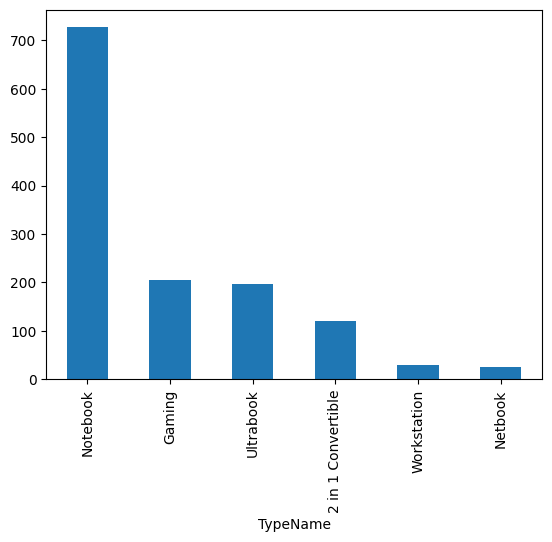

In [41]:
# type of laptops
df['TypeName'].value_counts().plot(kind='bar')

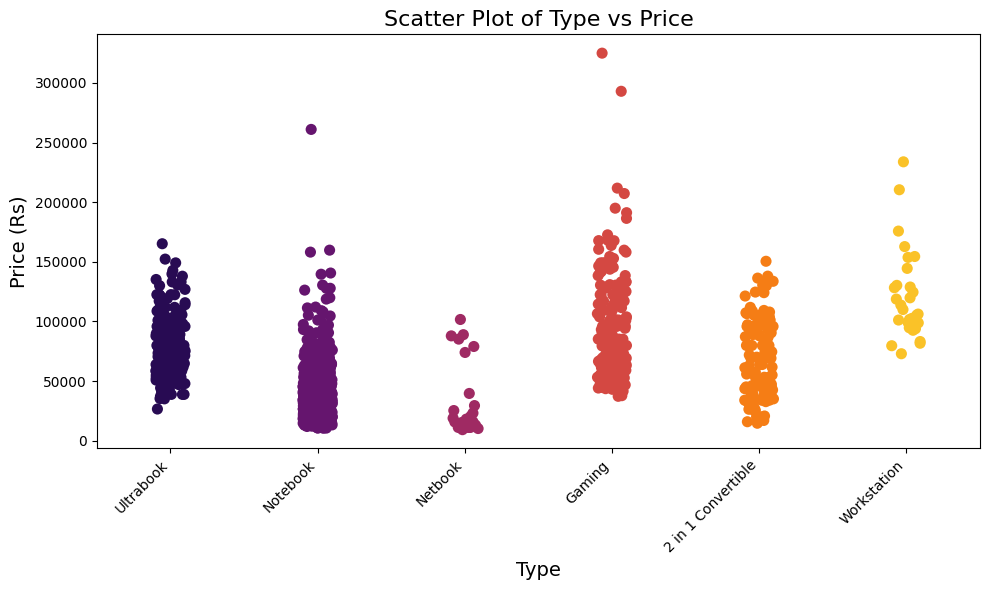

In [42]:
## Strip plot for TypeName vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='TypeName', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Type', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Type vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- **Notebook laptops, 2 in 1 convertible (laptop + Tablets) and Netbook laptops are mostly economical**
- **Gaming and Workstation laptops are generally costlier than the rest**

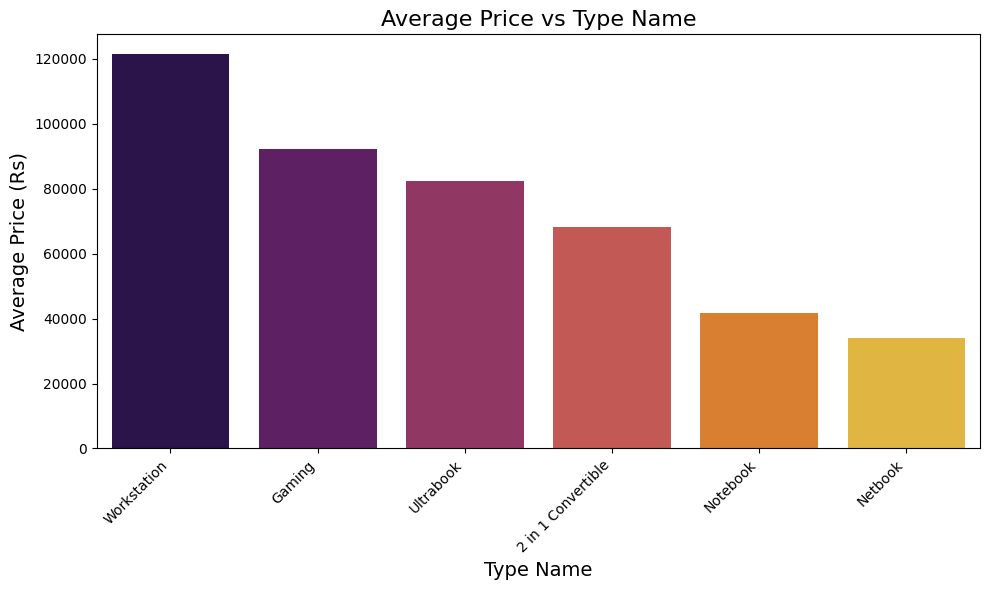

In [43]:
# Calculate mean prices for each RAM category
mean_prices = df.groupby('TypeName')['Price'].mean().reset_index()

# Sort the mean prices in descending order
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='TypeName', y='Price', data=mean_prices, palette='inferno')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('Type Name', fontsize=14)
plt.ylabel('Average Price (Rs)', fontsize=14)
plt.title('Average Price vs Type Name', fontsize=16)
plt.tight_layout()
plt.show()

### Size of the Laptop

In [44]:
df['Inches'].value_counts()

,count
Inches,
15.6,665
14.0,197
13.3,164
17.3,164
12.5,39
11.6,33
13.5,6
12.0,6
13.9,6


In [45]:
len(df['Inches'].value_counts())

18

**18 different sizes of laptops are available**

<Axes: xlabel='Inches', ylabel='Count'>

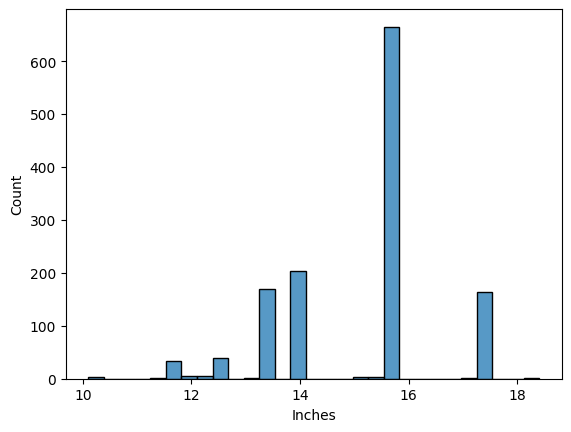

In [46]:
#size of the laptop
sns.histplot(df['Inches'], kde=False)

- **some of the laptops have rare screen sizes**
- **most of the laptops have 15.6 inch screen followed by 14 inch screen size and then 13.3 and 17.3 inch screen sizes.**

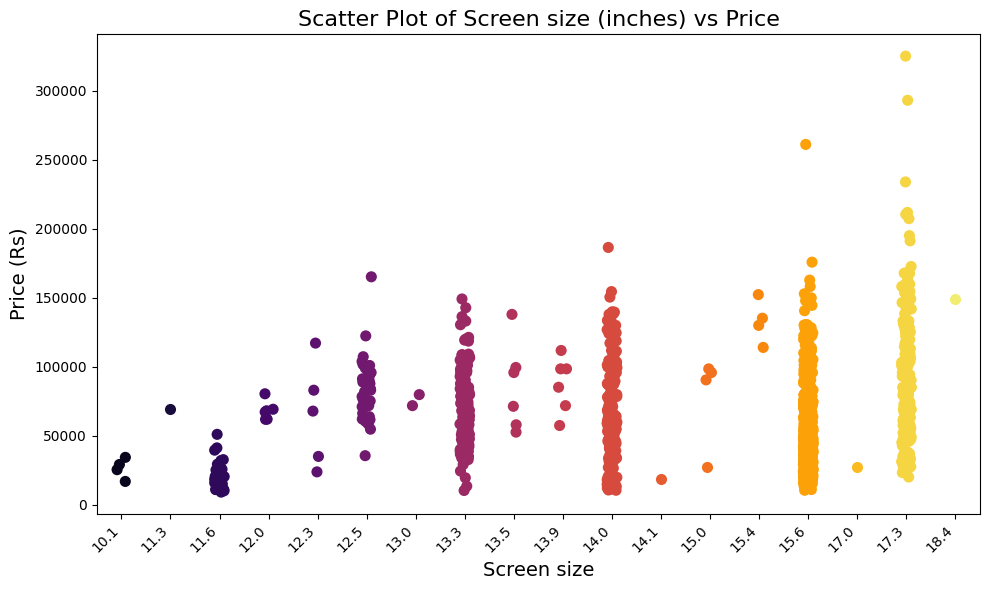

In [48]:
## Strip plot for TypeName vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='Inches', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Screen size', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Screen size (inches) vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

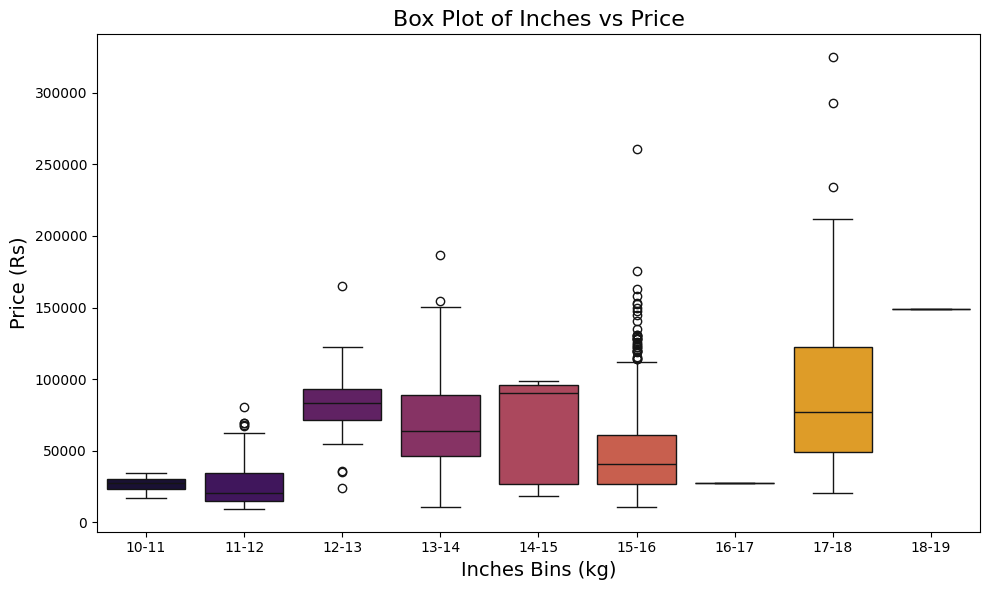

In [47]:
#Inches vs Price
# Bin the Weight into categories
bins = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]  # Adjust bin edges as necessary
labels = ['10-11', '11-12', '12-13', '13-14', '14-15', '15-16', '16-17', '17-18', '18-19']
df['Inches_Binned'] = pd.cut(df['Inches'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Inches_Binned', y='Price', data=df, palette='inferno')
plt.xlabel('Inches Bins (kg)', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Box Plot of Inches vs Price', fontsize=16)
plt.tight_layout()
plt.show()

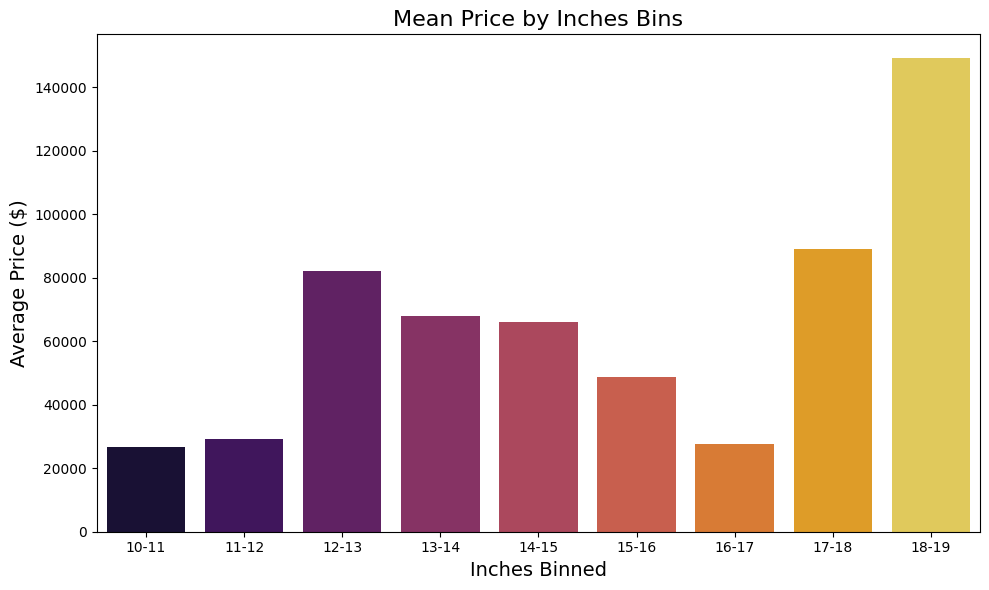

In [49]:
# Calculate mean prices for each Inches category
mean_prices = df.groupby('Inches_Binned')['Price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Inches_Binned', y='Price', data=mean_prices, palette='inferno')
plt.xlabel('Inches Binned', fontsize=14)
plt.ylabel('Average Price ($)', fontsize=14)
plt.title('Mean Price by Inches Bins', fontsize=16)
plt.tight_layout()
plt.show()

- **The price of laptops with screen size >17 inches are usually costlier as the mean price is generally 85K and above.**
- **Surprisingly the laptops with screen size 12-13 inches are generally costlier than the laptops having screen size 13-17 inches or 10-12 inches.**

### Screen Resolution

In [50]:
# A lot of different information about the screen
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


- **Most of the laptops are not touchscreen but there are considerable amount of touchscreen laptops too in the dataset**
- **In General, the cost of touchscreen laptops are higher than the normal laptops**

In [51]:
# if the laptop is touch screen then 1 otherwise 0
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df['Touchscreen']

,Touchscreen
0,0
1,0
2,0
3,0
4,0
...,...
1298,1
1299,1
1300,0
1301,0


In [52]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Weight_Binned,Inches_Binned,Touchscreen
371,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,128GB SSD,AMD Radeon R5,Windows 10,2.1,22697.28,2-3,15-16,0
277,Acer,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,1TB HDD,Nvidia GeForce MX130,Windows 10,2.2,39693.60,2-3,15-16,0
1207,Lenovo,Notebook,15.6,1366x768,AMD E-Series 9000 2.2GHz,4,500GB HDD,AMD Radeon R2 Graphics,Windows 10,2.2,15930.72,2-3,15-16,0
1202,Dell,2 in 1 Convertible,15.6,Full HD / Touchscreen 1920x1080,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Intel UHD Graphics 620,Windows 10,2.0,68464.80,1-2,15-16,1
1235,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,1TB HDD,Intel HD Graphics 520,Windows 10,2.1,25467.84,2-3,15-16,0


<Axes: xlabel='Touchscreen'>

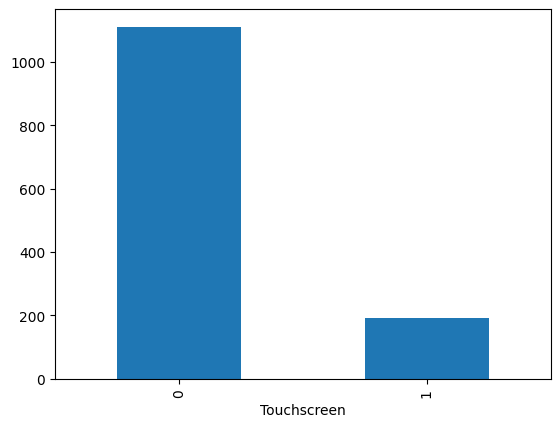

In [53]:
#plot for count of touchscreen and normal laptops
df['Touchscreen'].value_counts().plot(kind='bar')

In [55]:
df['Touchscreen'].value_counts()

,count
Touchscreen,
0,1111
1,192


**The touchscreen laptops are around 200 in count and the normal laptops are around 1100 in count**

<Axes: xlabel='Touchscreen', ylabel='Price'>

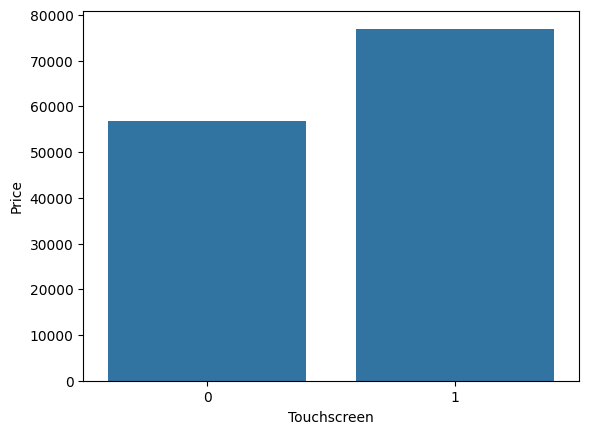

In [56]:
#touchscreen vs price plot
sns.barplot(x=df['Touchscreen'],y=df['Price'], ci =None)

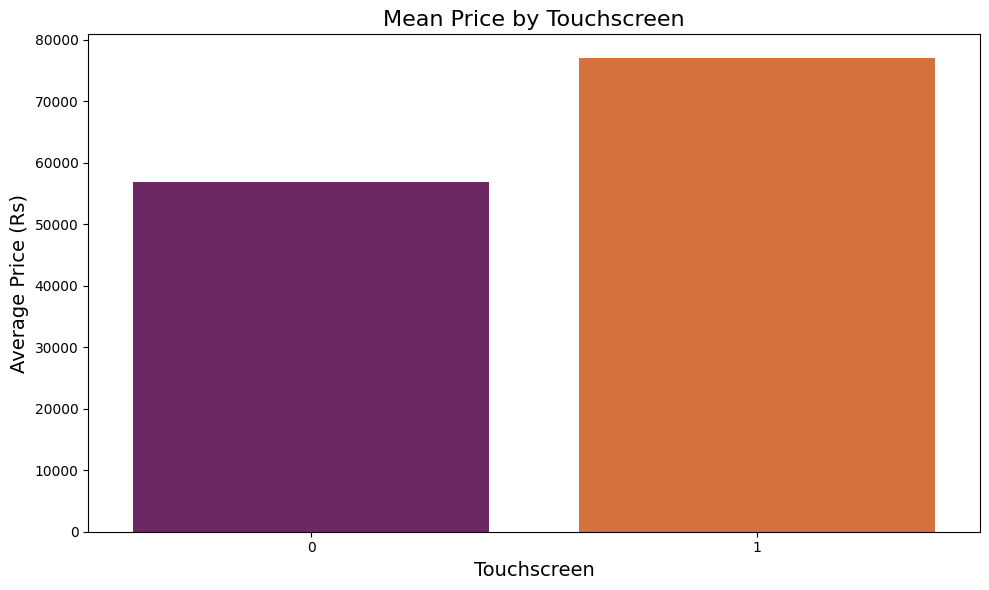

In [57]:
# Calculate mean prices for each Inches category
mean_prices = df.groupby('Touchscreen')['Price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Touchscreen', y='Price', data=mean_prices, palette='inferno')
plt.xlabel('Touchscreen', fontsize=14)
plt.ylabel('Average Price (Rs)', fontsize=14)
plt.title('Mean Price by Touchscreen', fontsize=16)
plt.tight_layout()
plt.show()

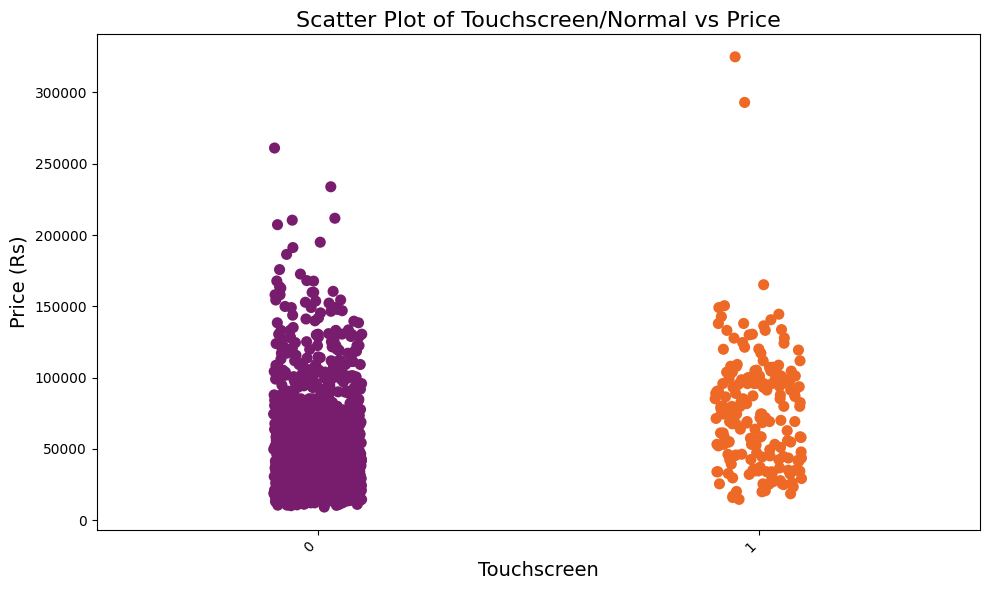

In [58]:
## Strip plot for TypeName vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='Touchscreen', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Touchscreen', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Touchscreen/Normal vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<Axes: xlabel='Touchscreen', ylabel='Price'>

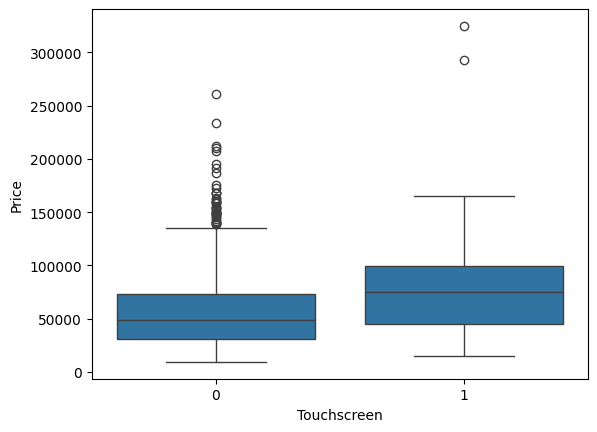

In [59]:
sns.boxplot(x='Touchscreen', y='Price', data=df)

**An IPS (In-Plane Switching) screen is a type of LCD (Liquid Crystal Display) technology used in laptops and other devices. IPS screens are known for their superior display quality compared to other types of LCDs, such as TN (Twisted Nematic) panels.**

In [60]:
#if screen has ips resolution then 1 otherwise 0
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df['Ips']

,Ips
0,1
1,0
2,0
3,1
4,1
...,...
1298,1
1299,1
1300,0
1301,0


In [61]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Weight_Binned,Inches_Binned,Touchscreen,Ips
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,1-2,13-14,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1-2,13-14,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1-2,15-16,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,1-2,15-16,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,1-2,13-14,0,1


Ips
0    938
1    365
Name: count, dtype: int64


<Axes: xlabel='Ips'>

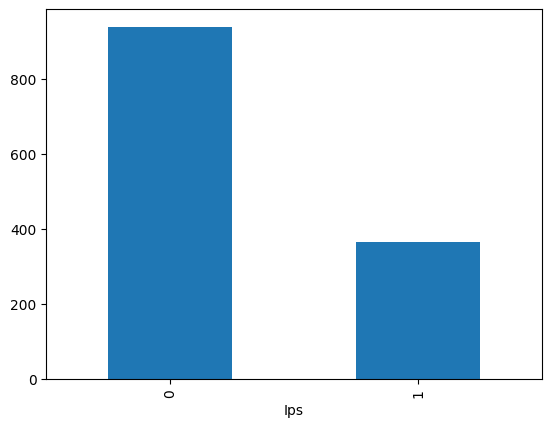

In [62]:
# Kitne laptops mai Ips screen hai - count k liye plot
print(df['Ips'].value_counts())
df['Ips'].value_counts().plot(kind='bar')

**Around 350+ laptops have IPS screens and rest do not have them**

<Axes: xlabel='Ips', ylabel='Price'>

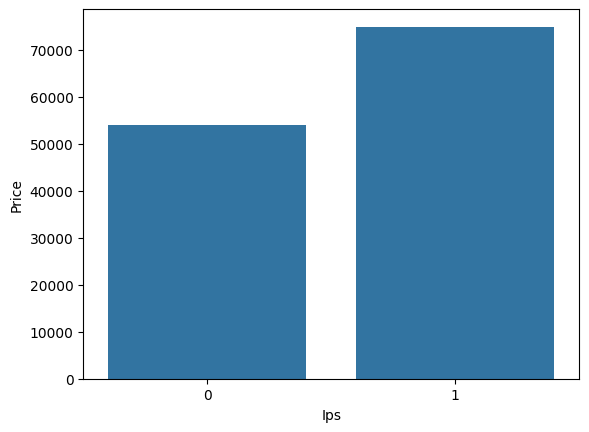

In [63]:
sns.barplot(x=df['Ips'],y=df['Price'], ci=None)

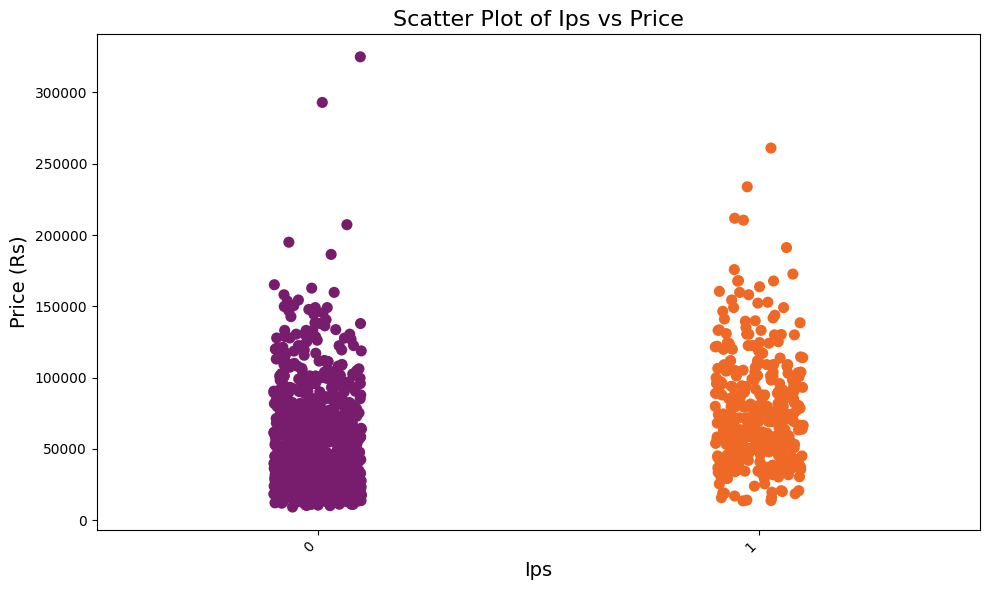

In [64]:
## Strip plot for TypeName vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='Ips', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Ips', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Ips vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='Ips', ylabel='Price'>

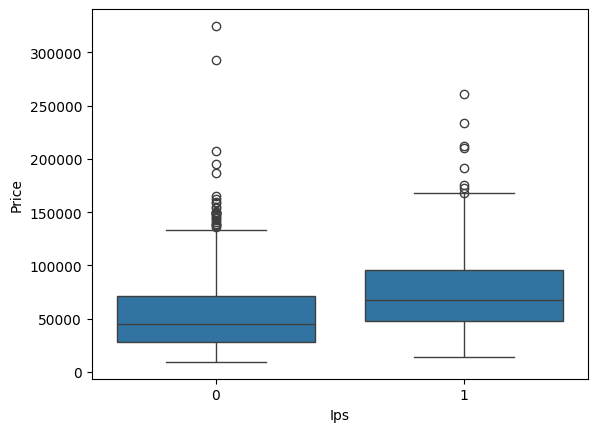

In [65]:
# boxplot to confirm the relation between Ips and pricing
sns.boxplot(x='Ips', y='Price', data=df)

**Ips laptops are usually costlier than the rest**

**Abb Screen resolution ko dekhte h**

In [66]:
#in order to break the screen resolution in (x_res)*(y_res)
new = df['ScreenResolution'].str.split('x',n=1,expand=True)
new

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1298,IPS Panel Full HD / Touchscreen 1920,1080
1299,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,1366,768
1301,1366,768


In [67]:
#y_resolution seperated successfully but still a problem with the x_resolution
df['X_res'] = new[0]
df['Y_res'] = new[1]

In [68]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Weight_Binned,Inches_Binned,Touchscreen,Ips,X_res,Y_res
1135,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,16,1.0TB Hybrid,AMD Radeon R7 M360,Windows 10,2.50,58554.72,2-3,15-16,0,0,Full HD 1920,1080
326,Acer,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,6,1TB HDD,Intel HD Graphics 620,Windows 10,2.23,29250.72,2-3,15-16,0,0,1366,768
705,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,2.18,42357.60,2-3,15-16,0,0,Full HD 1920,1080
623,Fujitsu,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,2.20,42570.72,2-3,15-16,0,0,1366,768
976,Lenovo,Notebook,14.0,1366x768,Intel Core i5 6200U 2.3GHz,4,508GB Hybrid,Intel HD Graphics 520,Windows 7,1.70,53386.56,1-2,13-14,0,0,1366,768


In [69]:
#x_res seperated successfully
df['X_res'] = df['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [70]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Weight_Binned,Inches_Binned,Touchscreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,1-2,13-14,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1-2,13-14,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1-2,15-16,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,1-2,15-16,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,1-2,13-14,0,1,2560,1600


In [71]:
#converting the x_res and y_res in integers
df['X_res'] = df['X_res'].astype('int')
df['Y_res'] = df['Y_res'].astype('int')

In [72]:
df['X_res'].value_counts()

,count
X_res,
1920,846
1366,308
3840,43
2560,29
3200,27
1600,23
2304,6
2256,6
1440,4


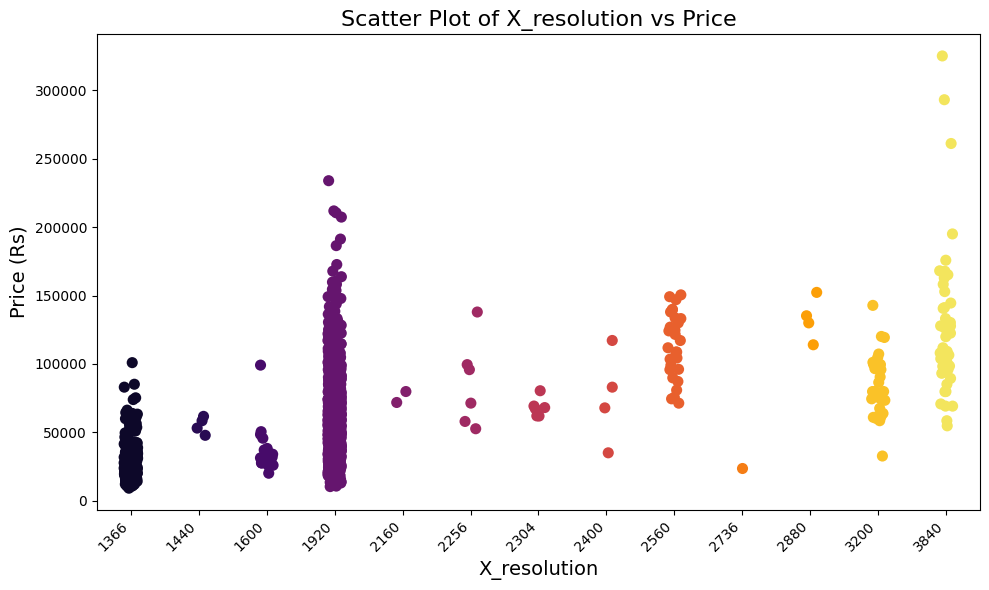

In [73]:
## Strip plot for TypeName vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='X_res', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('X_resolution', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of X_resolution vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

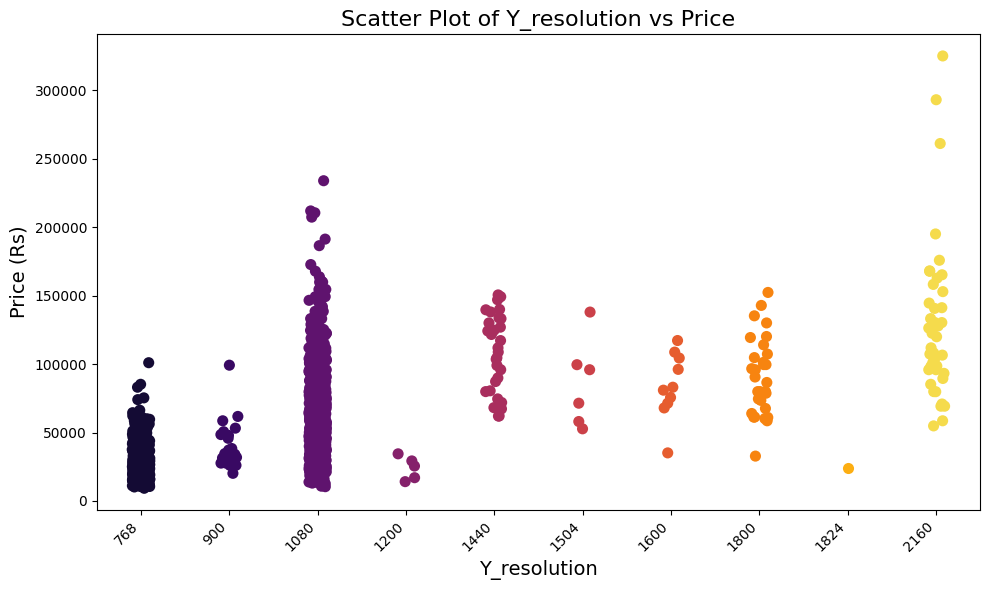

In [74]:
## Strip plot for TypeName vs Price
plt.figure(figsize=(10, 6))
sns.stripplot(x='Y_res', y='Price', data=df, jitter=0.1, palette='inferno', size=8)
plt.xlabel('Y_resolution', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Scatter Plot of Y_resolution vs Price', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Company           1303 non-null   object  
 1   TypeName          1303 non-null   object  
 2   Inches            1303 non-null   float64 
 3   ScreenResolution  1303 non-null   object  
 4   Cpu               1303 non-null   object  
 5   Ram               1303 non-null   int64   
 6   Memory            1303 non-null   object  
 7   Gpu               1303 non-null   object  
 8   OpSys             1303 non-null   object  
 9   Weight            1303 non-null   float64 
 10  Price             1303 non-null   float64 
 11  Weight_Binned     1303 non-null   category
 12  Inches_Binned     1303 non-null   category
 13  Touchscreen       1303 non-null   int64   
 14  Ips               1303 non-null   int64   
 15  X_res             1303 non-null   int64   
 16  Y_res             1303 n

In [85]:
df_numeric = df.select_dtypes(include=np.number)
df_numeric.corr()['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
Ips,0.252208
X_res,0.556529
Y_res,0.552809


### New Feature = PPI (price per inches)

In [86]:
#creating a new column ppi= price per inches using its formula (google)
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Weight_Binned,Inches_Binned,Touchscreen,Ips,X_res,Y_res,ppi
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,1-2,13-14,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1-2,13-14,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1-2,15-16,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,1-2,15-16,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,1-2,13-14,0,1,2560,1600,226.983005


In [87]:
df['ppi'].value_counts()

,count
ppi,
141.211998,430
100.454670,212
157.350512,133
127.335675,131
165.632118,110
111.935204,45
135.094211,31
276.053530,27
176.232574,25


In [90]:
df_numeric = df.select_dtypes(include=np.number)
df_numeric.corr()['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
Ips,0.252208
X_res,0.556529
Y_res,0.552809
ppi,0.473487


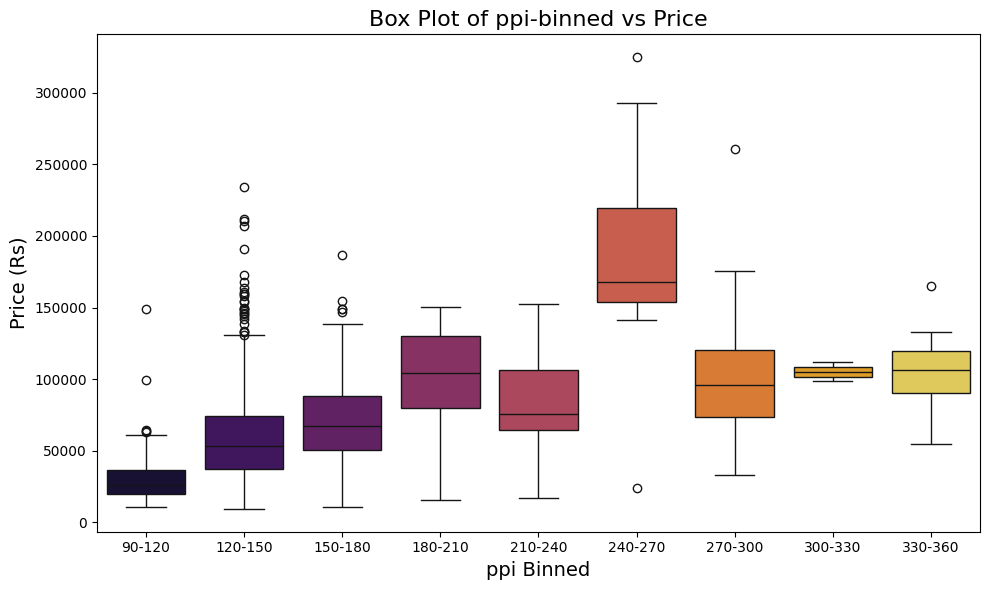

In [91]:
#ppi vs Price
# Bin the Weight into categories
bins = [90, 120, 150, 180, 210, 240, 270, 300, 330, 360]  # Adjust bin edges as necessary
labels = ['90-120', '120-150', '150-180', '180-210', '210-240', '240-270', '270-300', '300-330', '330-360']
df['ppi_Binned'] = pd.cut(df['ppi'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.boxplot(x='ppi_Binned', y='Price', data=df, palette='inferno')
plt.xlabel('ppi Binned', fontsize=14)
plt.ylabel('Price (Rs)', fontsize=14)
plt.title('Box Plot of ppi-binned vs Price', fontsize=16)
plt.tight_layout()
plt.show()

In [92]:
#dropping screenresolution
df.drop(columns=['ScreenResolution'],inplace=True)

In [93]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Weight_Binned,Inches_Binned,Touchscreen,Ips,X_res,Y_res,ppi,ppi_Binned
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,1-2,13-14,0,1,2560,1600,226.983005,210-240
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1-2,13-14,0,0,1440,900,127.677940,120-150
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1-2,15-16,0,0,1920,1080,141.211998,120-150
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,1-2,15-16,0,1,2880,1800,220.534624,210-240
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,1-2,13-14,0,1,2560,1600,226.983005,210-240


In [94]:
df_correlation = df.select_dtypes(include=np.number)
df_correlation.corr()

,Inches,Ram,Weight,Price,Touchscreen,Ips,X_res,Y_res,ppi
Inches,1.000000,0.237993,0.827631,0.068197,-0.361735,-0.114804,-0.071245,-0.095404,-0.414804
Ram,0.237993,1.000000,0.383874,0.743007,0.116984,0.206623,0.433121,0.424437,0.303763
Weight,0.827631,0.383874,1.000000,0.210370,-0.294620,0.016967,-0.032880,-0.053846,-0.323240
Price,0.068197,0.743007,0.210370,1.000000,0.191226,0.252208,0.556529,0.552809,0.473487
Touchscreen,-0.361735,0.116984,-0.294620,0.191226,1.000000,0.150512,0.351066,0.357930,0.460587
Ips,-0.114804,0.206623,0.016967,0.252208,0.150512,1.000000,0.281457,0.289030,0.300879
X_res,-0.071245,0.433121,-0.032880,0.556529,0.351066,0.281457,1.000000,0.994219,0.931217
Y_res,-0.095404,0.424437,-0.053846,0.552809,0.357930,0.289030,0.994219,1.000000,0.939363
ppi,-0.414804,0.303763,-0.323240,0.473487,0.460587,0.300879,0.931217,0.939363,1.000000


<Axes: >

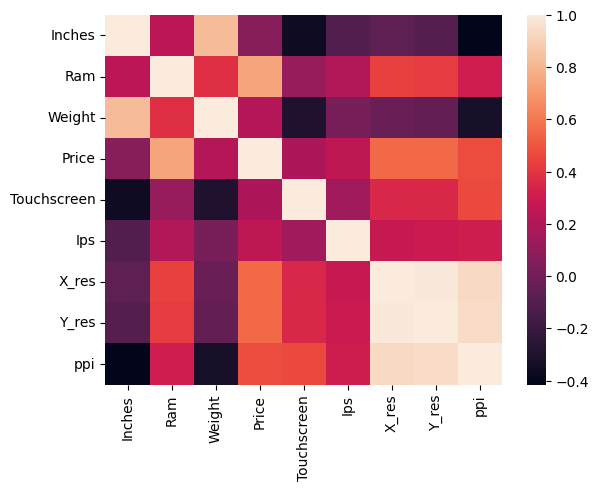

In [95]:
sns.heatmap(df_correlation.corr())

In [96]:
#since we have already created 'ppi'column therefore removing columns such as 'Inches', 'X-res', 'Y-res', 'Weight_Binned', 'Inches_Binned', 'ppi_Binned'
df.drop(columns=['Inches','X_res','Y_res', 'Weight_Binned', 'Inches_Binned', 'ppi_Binned'],inplace=True)

In [97]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


### CPU

In [98]:
#cpu category
print(df['Cpu'].value_counts())
print("-"*40)
print(len(df['Cpu'].value_counts()))

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64
----------------------------------------
118


In [99]:
#extracting first three words from the cpu category column
df['Cpu Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))
# now checking the number of categories
df['Cpu Name'].value_counts()

,count
Cpu Name,
Intel Core i7,527
Intel Core i5,423
Intel Core i3,136
Intel Celeron Dual,80
Intel Pentium Quad,27
Intel Core M,19
AMD A9-Series 9420,12
AMD A6-Series 9220,8
Intel Celeron Quad,8


In [100]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [101]:
len(df['Cpu Name'].value_counts())

40

**40 categories in the CPU name itself --> still a problem**

In [102]:
#breaking the whole category into 5 main categories = intel core i3/i5/i7 otherwise 'oter intel processor' or else 'amd processor'
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [103]:
#storing these categories in a new column - Cpu brand
df['Cpu brand'] = df['Cpu Name'].apply(fetch_processor)
df['Cpu brand']

,Cpu brand
0,Intel Core i5
1,Intel Core i5
2,Intel Core i5
3,Intel Core i7
4,Intel Core i5
...,...
1298,Intel Core i7
1299,Intel Core i7
1300,Other Intel Processor
1301,Intel Core i7


In [104]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu Name,Cpu brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


<Axes: xlabel='Cpu brand'>

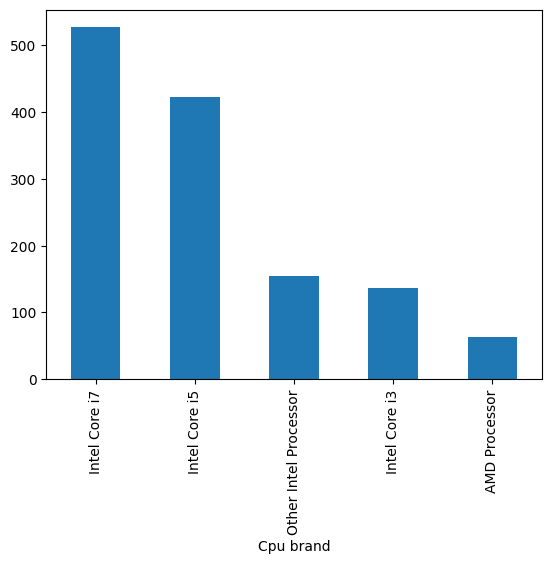

In [105]:
#cpu brand wise counts
df['Cpu brand'].value_counts().plot(kind='bar')

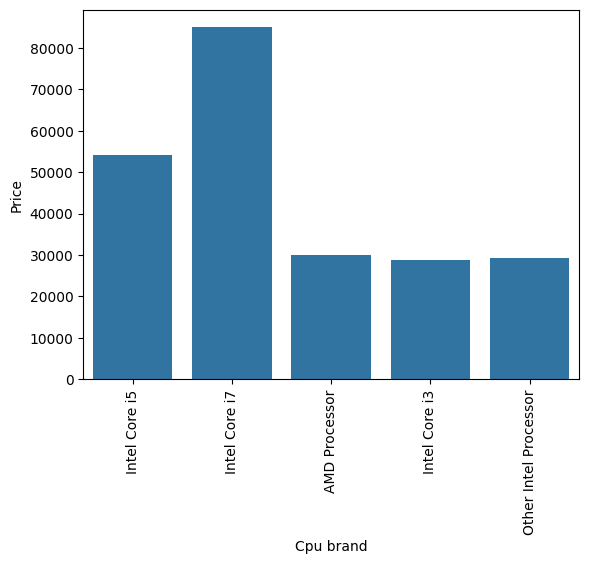

In [106]:
#cpu brand vs price
sns.barplot(x=df['Cpu brand'],y=df['Price'],ci=None)
plt.xticks(rotation='vertical')
plt.show()

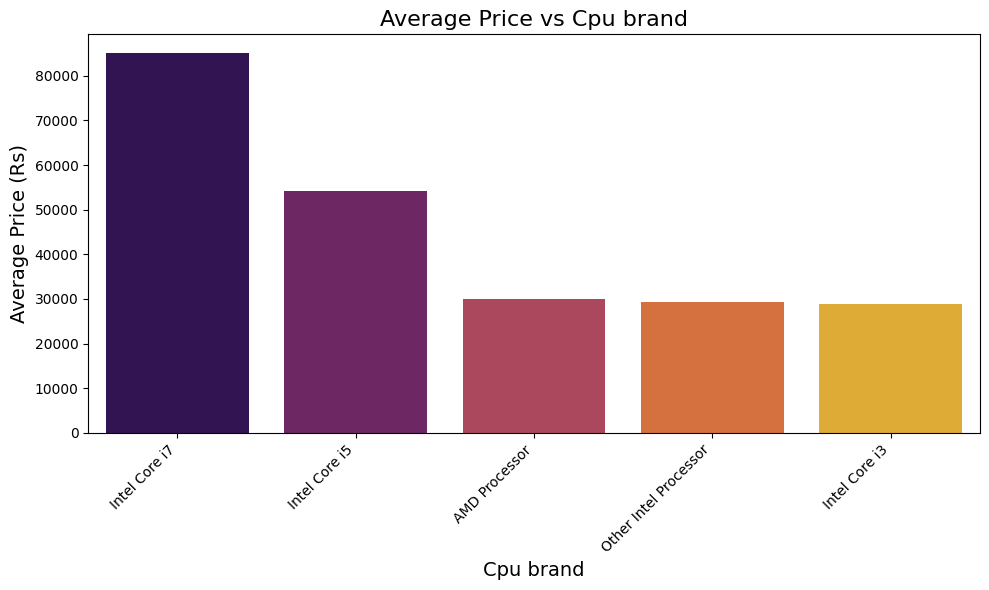

In [107]:
# Calculate mean prices for each RAM category
mean_prices = df.groupby('Cpu brand')['Price'].mean().reset_index()

# Sort the mean prices in descending order
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Cpu brand', y='Price', data=mean_prices, palette='inferno')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('Cpu brand', fontsize=14)
plt.ylabel('Average Price (Rs)', fontsize=14)
plt.title('Average Price vs Cpu brand', fontsize=16)
plt.tight_layout()
plt.show()

**CPU aur CPU Name features ka abb koi kaam nahi ---> Deleting it**

In [108]:
#dropping the 'Cpu' and 'Cpu Name' columns = unnecessary
df.drop(columns=['Cpu','Cpu Name'],inplace=True,errors='ignore')

In [109]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


### Memory

In [110]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [115]:
#breaking the 'Memory' column into 4 new columns i.e HDD, SSD, Hybrid, Flash

df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '', regex=False)
df["Memory"] = df["Memory"].str.replace('TB', '000', regex=False)
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '', regex=True)

df["second"].fillna("0", inplace = True)

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

In [116]:
df

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,...,Layer1Hybrid,Layer1Flash_Storage,Layer2HDD,Layer2SSD,Layer2Hybrid,Layer2Flash_Storage,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,...,0,0,0,0,0,0,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,...,0,1,0,0,0,0,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,...,0,0,0,0,0,0,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,...,0,0,0,0,0,0,0,512,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,...,0,0,0,0,0,0,0,256,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,128 SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,...,0,0,0,0,0,0,0,128,0,0
1299,Lenovo,2 in 1 Convertible,16,512 SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,...,0,0,0,0,0,0,0,512,0,0
1300,Lenovo,Notebook,2,64 Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,...,0,1,0,0,0,0,0,0,0,64
1301,HP,Notebook,6,1000 HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,...,0,0,0,0,0,0,1000,0,0,0


In [117]:
df[['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid','Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid','Layer2Flash_Storage']]

,first,second,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash_Storage,Layer2HDD,Layer2SSD,Layer2Hybrid,Layer2Flash_Storage
0,128,0,0,1,0,0,0,0,0,0
1,128,0,0,0,0,1,0,0,0,0
2,256,0,0,1,0,0,0,0,0,0
3,512,0,0,1,0,0,0,0,0,0
4,256,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1298,128,0,0,1,0,0,0,0,0,0
1299,512,0,0,1,0,0,0,0,0,0
1300,64,0,0,0,0,1,0,0,0,0
1301,1000,0,1,0,0,0,0,0,0,0


In [118]:
df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid','Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid','Layer2Flash_Storage'],inplace=True, errors='ignore')

In [119]:
df.sample(15)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
202,Acer,Notebook,8,1000 HDD,Nvidia GeForce 940MX,Windows 10,2.23,39533.760,0,0,141.211998,Intel Core i7,1000,0,0,0
845,Dell,Notebook,4,256 SSD,AMD Radeon R5 M420,Windows 10,2.18,39373.920,0,0,141.211998,Intel Core i7,0,256,0,0
1041,Vero,Notebook,2,32 Flash Storage,Intel HD Graphics 400,Windows 10,1.45,11231.424,0,0,111.935204,Other Intel Processor,0,0,0,32
241,Asus,Notebook,8,128 SSD + 1000 HDD,Nvidia GeForce 150MX,Windows 10,2.10,61005.600,0,0,127.335675,Intel Core i7,1000,128,0,0
214,Huawei,Ultrabook,8,512 SSD,Intel HD Graphics 620,Windows 10,1.05,79866.720,0,1,199.692071,Intel Core i7,0,512,0,0
19,Dell,Ultrabook,8,128 SSD,Intel UHD Graphics 620,Windows 10,1.22,52161.120,1,1,165.632118,Intel Core i5,0,128,0,0
853,Lenovo,Ultrabook,8,256 SSD,Nvidia GeForce GT 940MX,Windows 10,1.96,101391.840,0,1,157.350512,Intel Core i7,0,256,0,0
572,HP,Notebook,6,256 SSD,AMD Radeon 530,Windows 10,1.95,34578.720,0,1,141.211998,AMD Processor,0,256,0,0
811,MSI,Gaming,16,512 SSD + 1000 HDD,Nvidia GeForce GTX 1070,Windows 10,2.90,128671.200,0,0,127.335675,Intel Core i7,1000,512,0,0
617,HP,Ultrabook,8,512 SSD,Intel HD Graphics 620,Windows 10,1.84,74005.920,0,0,141.211998,Intel Core i7,0,512,0,0


In [125]:
df.drop(columns=['Memory'],inplace=True,errors='ignore')

In [126]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0


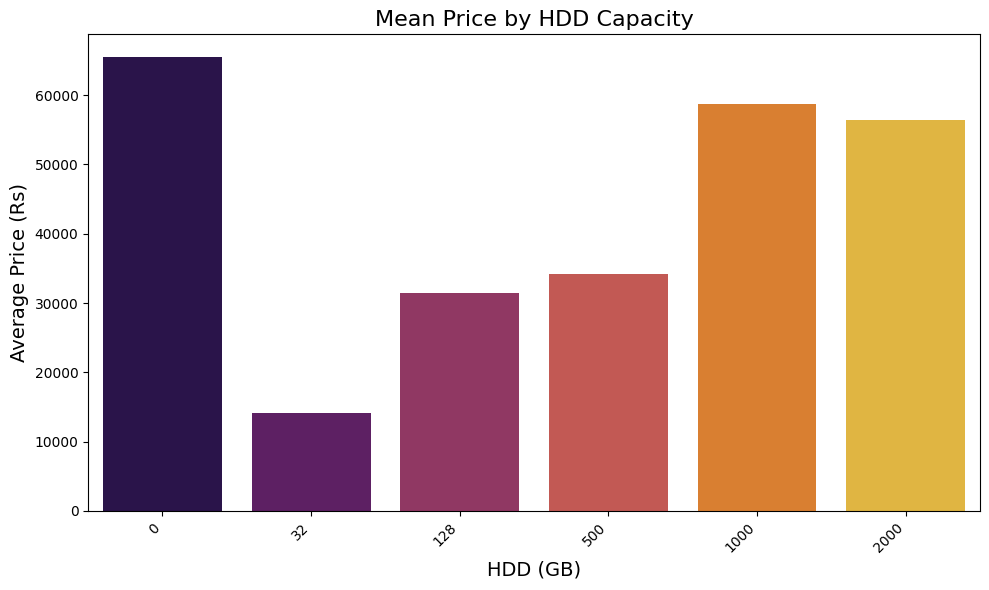

In [128]:
## HDD vs price
# Calculate the mean prices for each HDD category
mean_prices = df.groupby('HDD')['Price'].mean().reset_index()

# Sort the mean prices in descending order for better visualization
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='HDD', y='Price', data=mean_prices, palette='inferno', ci=None)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('HDD (GB)', fontsize=14)
plt.ylabel('Average Price (Rs)', fontsize=14)
plt.title('Mean Price by HDD Capacity', fontsize=16)
plt.tight_layout()
plt.show()

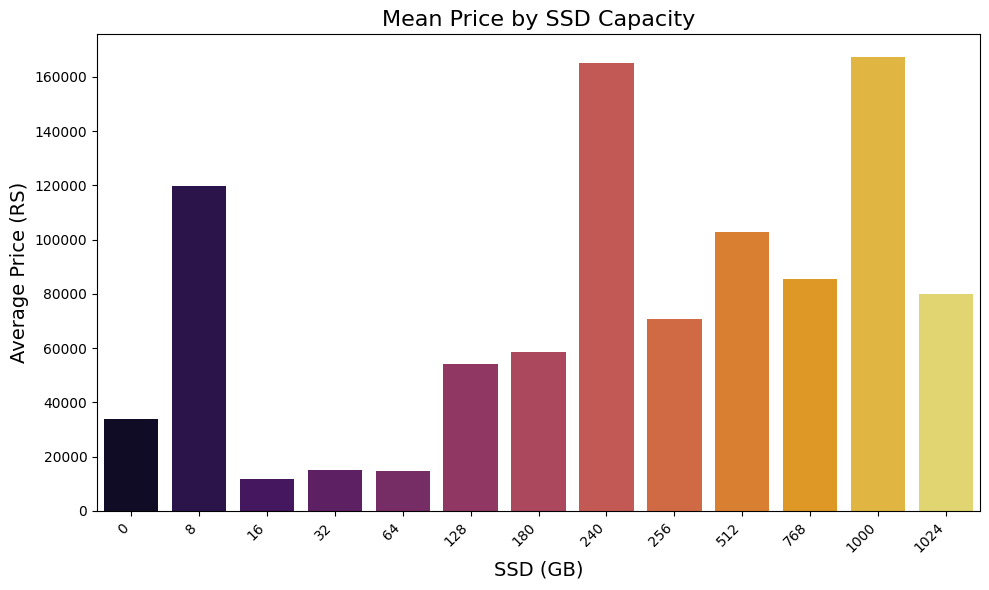

In [129]:
## SSD vs price
# Calculate the mean prices for each HDD category
mean_prices = df.groupby('SSD')['Price'].mean().reset_index()

# Sort the mean prices in descending order for better visualization
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='SSD', y='Price', data=mean_prices, palette='inferno', ci=None)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('SSD (GB)', fontsize=14)
plt.ylabel('Average Price (RS)', fontsize=14)
plt.title('Mean Price by SSD Capacity', fontsize=16)
plt.tight_layout()

# Display the plot
plt.show()

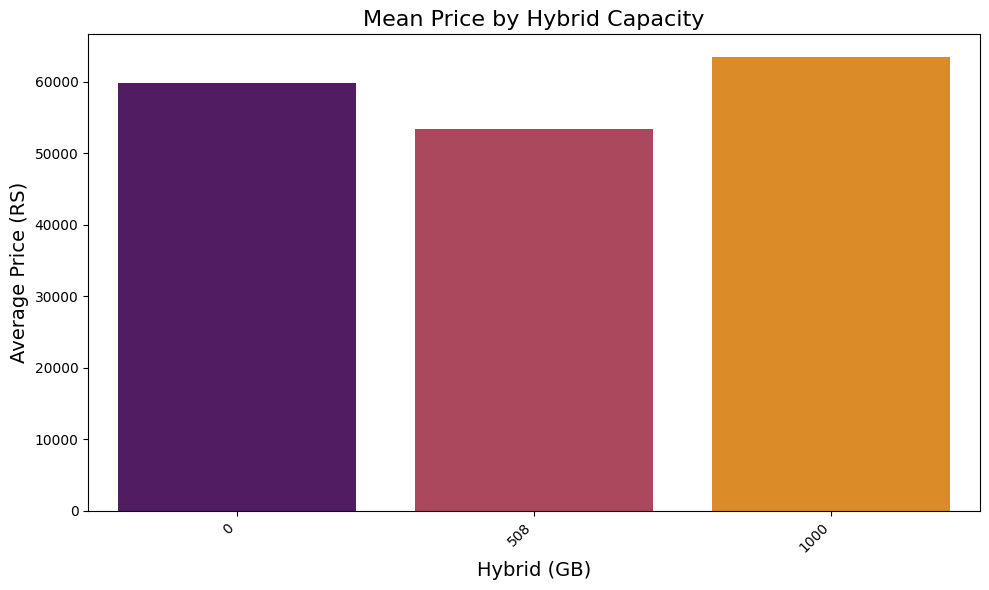

In [130]:
## Hybrid vs price

# Calculate the mean prices for each HDD category
mean_prices = df.groupby('Hybrid')['Price'].mean().reset_index()

# Sort the mean prices in descending order for better visualization
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Hybrid', y='Price', data=mean_prices, palette='inferno', ci=None)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('Hybrid (GB)', fontsize=14)
plt.ylabel('Average Price (RS)', fontsize=14)
plt.title('Mean Price by Hybrid Capacity', fontsize=16)
plt.tight_layout()
plt.show()

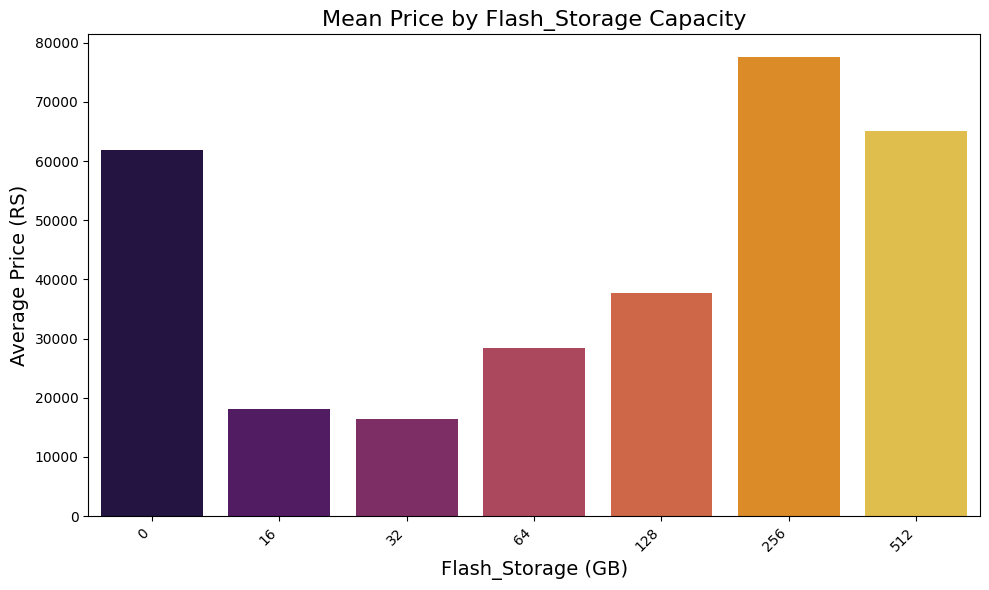

In [131]:
## Flash_Storage vs price

# Calculate the mean prices for each HDD category
mean_prices = df.groupby('Flash_Storage')['Price'].mean().reset_index()

# Sort the mean prices in descending order for better visualization
mean_prices = mean_prices.sort_values(by='Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Flash_Storage', y='Price', data=mean_prices, palette='inferno', ci=None)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel('Flash_Storage (GB)', fontsize=14)
plt.ylabel('Average Price (RS)', fontsize=14)
plt.title('Mean Price by Flash_Storage Capacity', fontsize=16)
plt.tight_layout()
plt.show()


In [137]:
df.corr(numeric_only=True)['Price']

,Price
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
Ips,0.252208
ppi,0.473487
HDD,-0.096441
SSD,0.670799
Hybrid,0.007989
Flash_Storage,-0.040511


In [138]:
#dropping 'Hybrid' and 'Flash_Storage' because of very less correlation
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256


### Gpu

In [139]:
#Gpu column
df['Gpu'].value_counts()

,count
Gpu,
Intel HD Graphics 620,281
Intel HD Graphics 520,185
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48
...,...
Nvidia Quadro M500M,1
AMD Radeon R7 M360,1
Nvidia Quadro M3000M,1


In [140]:
len(df['Gpu'].value_counts())

110

**There are a total of 110 categories of GPU**

In [141]:
#extracting GPU brand name from the GPU column
df['Gpu brand'] = df['Gpu'].apply(lambda x:x.split()[0])
df['Gpu brand'].value_counts()

,count
Gpu brand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [142]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [143]:
#dropping the row contating "ARM" as GPU brand (only 1 row)
df = df[df['Gpu brand'] != 'ARM']
df

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7,0,128,Intel
1299,Lenovo,2 in 1 Convertible,16,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7,0,512,Intel
1300,Lenovo,Notebook,2,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,Other Intel Processor,0,0,Intel
1301,HP,Notebook,6,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7,1000,0,AMD


In [144]:
df['Gpu brand'].value_counts()

,count
Gpu brand,
Intel,722
Nvidia,400
AMD,180


**Finally sirf 3 GPU k brands hi h abb humare pass**

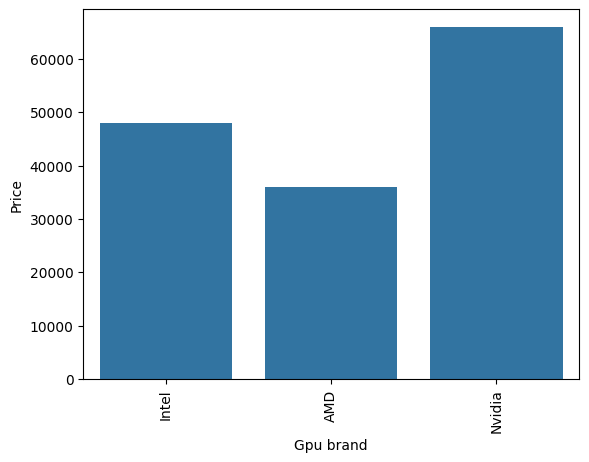

In [146]:
sns.barplot(x=df['Gpu brand'],y=df['Price'],estimator=np.median, ci=None)
plt.xticks(rotation='vertical')
plt.show()

In [149]:
#dropping the GPU column
df.drop(columns=['Gpu'],inplace=True,errors='ignore')

In [150]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


### Operating System

In [151]:
#OpSys column
df['OpSys'].value_counts()

,count
OpSys,
Windows 10,1072
No OS,66
Linux,62
Windows 7,45
Chrome OS,26
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


In [152]:
len(df['OpSys'].value_counts())

9

**Total 9 alag alag categories h operating systems ki**

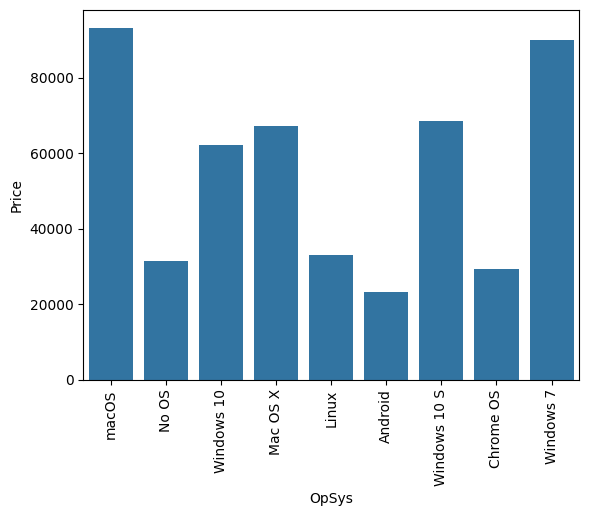

In [153]:
#os wise price plot - mean price
sns.barplot(x=df['OpSys'],y=df['Price'], ci=None)
plt.xticks(rotation='vertical')
plt.show()

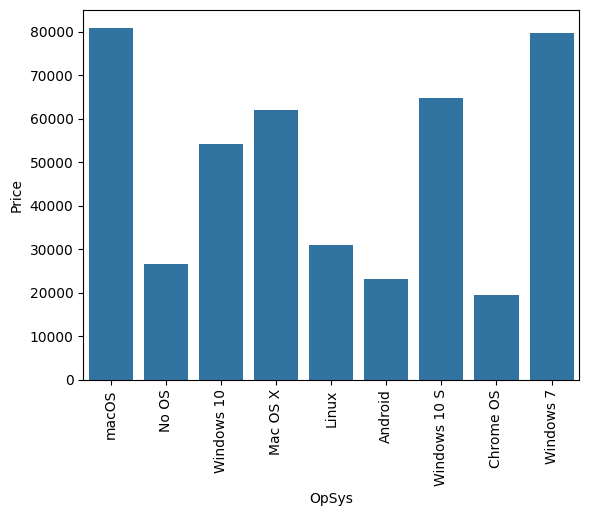

In [154]:
#os wise price plot - median price
sns.barplot(x=df['OpSys'],y=df['Price'], ci=None, estimator ='median')
plt.xticks(rotation='vertical')
plt.show()

In [155]:
# converting all the os systems into 3 categories only, 'windows', 'mac', 'Others/No OS/Linux'
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [156]:
## inn changes ko ek new feature "os" mai store kar rhe h
df['os'] = df['OpSys'].apply(cat_os)
df['os']

,os
0,Mac
1,Mac
2,Others/No OS/Linux
3,Mac
4,Mac
...,...
1298,Windows
1299,Windows
1300,Windows
1301,Windows


In [157]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


**Abb hum 'OpSys' feature ko hata sakte h (delete)**

In [158]:
df.drop(columns=['OpSys'],inplace=True ,errors='ignore')

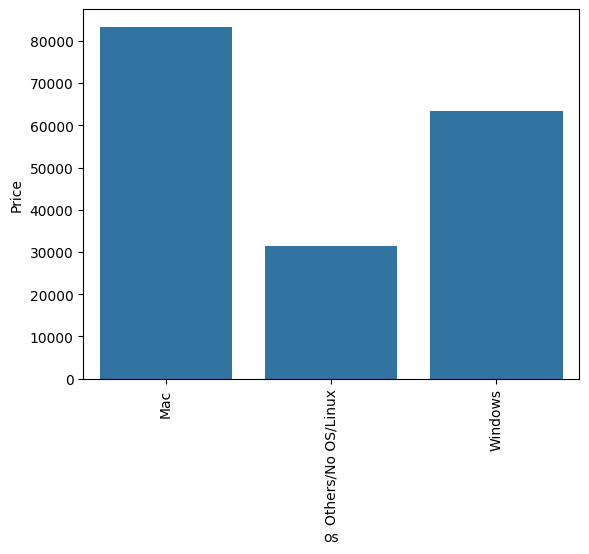

In [159]:
sns.barplot(x=df['os'],y=df['Price'], ci=None)
plt.xticks(rotation='vertical')
plt.show()

**Overall Mac operating system (OS) k laptops zyada costly h aur fir windows OS aur last mai Others**

### Correlation plot

In [166]:
df.corr(numeric_only=True)['Price']

,Price
Ram,0.742905
Weight,0.209867
Price,1.000000
Touchscreen,0.192917
Ips,0.253320
ppi,0.475368
HDD,-0.096891
SSD,0.670660


<Axes: >

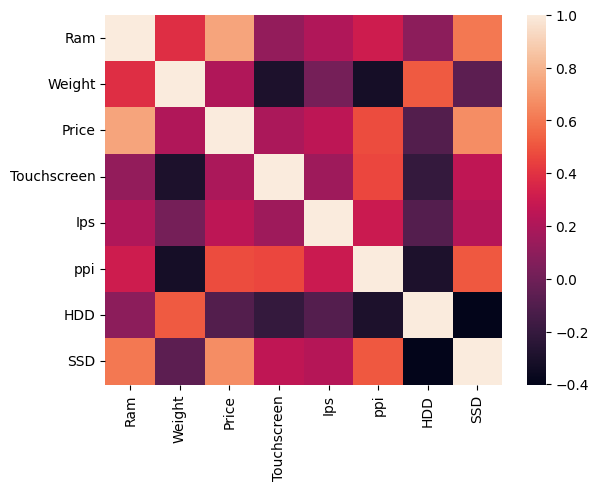

In [168]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='Price', ylabel='Density'>

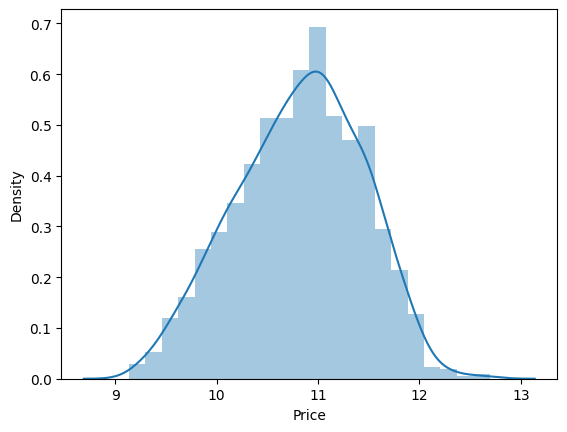

In [169]:
sns.distplot(np.log(df['Price']))

In [171]:
df.to_csv('laptop_clean_data.csv')

In [172]:
df

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,33992.6400,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,79866.7200,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1300,Lenovo,Notebook,2,1.50,12201.1200,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1301,HP,Notebook,6,2.19,40705.9200,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


In [173]:
df.to_excel('laptop_clean_data.xlsx', index=False)

The `df` DataFrame has been successfully saved as `laptop_clean_data.xlsx` in your Colab environment. You can download this file from the file browser on the left.

In [175]:
df=pd.read_excel('/content/laptop_clean_data.xlsx')
df

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1297,Lenovo,2 in 1 Convertible,4,1.80,33992.6400,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1298,Lenovo,2 in 1 Convertible,16,1.30,79866.7200,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1299,Lenovo,Notebook,2,1.50,12201.1200,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1300,HP,Notebook,6,2.19,40705.9200,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows
